# 实验二-Numpy和Pandas基础

<table style="margin: 0 auto; width: 30%; border-collapse: collapse; border: 1px solid black;" data-id="student-info">  
    <colgroup>  
        <col style="width: 35%;">  
        <col style="width: 65%;">  
    </colgroup>  
    <tr>  
        <td style="border: 1px solid black;">班级</td> <td style="border: 1px solid black;">25计科</td>  
    </tr>  
    <tr>  
        <td style="border: 1px solid black;">学号</td> <td style="border: 1px solid black;">未填写</td>  
    </tr>  
    <tr>  
        <td style="border: 1px solid black;">姓名</td> <td style="border: 1px solid black;">未填写</td>  
    </tr>  
    <tr>  
        <td style="border: 1px solid black;">Email</td> <td style="border: 1px solid black;">未填写</td>  
    </tr>  
</table>

## 实验目的

本次实验主要学习和掌握下列内容

- 向量化
- Numpy
- Pandas

## AI使用指南

使用AI编程已经非常普遍，我们的实验允许大家使用AI辅助编程，但请注意下面几点：

1. 在使用AI解决问题时（包括实验习题和讨论习题），请尽量尝试自己思考如何解决该问题，如果解题出错，再交给AI来解答，这样才会更加印象深刻，真正提高思考能力。
2. 如果完全不知道如何动手，可以将题目交给AI，让AI给出提示，先根据提示来尝试解题，如果出错再让AI来解释错误，这样会更加有效。
3. 请阅读AI生成的实验代码，看自己是否理解代码的含义，如果有不理解的地方，可以让AI来解释代码。
4. 完成所有实验生成实验报告的pdf文件后，请将实验报告上传给AI生成本次实验的测验，检测一下自己本次实验的掌握程度。

## Jupyter Notebook使用指导 

1. 首先选择Python内核：在右上角点击Kernel，选择venv(...)。
2. 在编辑后首先要保存，使用Ctrl+S保存。
3. 实验运行出现问题，并且代码正确，一个最常见的解决方法在最上方点击重启(Restart), 然后点击运行所有（Run All）。
4. 如果仍然出现问题，请保存后关闭notebook，然后重复步骤3。

## 实验准备

首先，让我们运行下面的单元格来导入您在此作业中需要的所有包, 并且为实验的代码的测试做准备。

In [1]:
# 导入需要的Python包
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys
from IPython.display import display, Image

# 获取项目根目录
project_root = Path().resolve().parent
sys.path.append(str(project_root / 'tests'))
sys.path.append(str(project_root / 'util'))

# 导入测试套件和其他工具
from test_suite2 import TestSuite2
from lr_utils import load_dataset
from notebook2pdf import convert_notebook_to_webpdf
from notebook_info_extractor import extract_from_ipynb
from IPython import get_ipython

testsuite2 = TestSuite2()

ip = get_ipython()
notebook_file = None
if '__vsc_ipynb_file__' in ip.user_ns:
    notebook_file = ip.user_ns['__vsc_ipynb_file__']

stu_info = extract_from_ipynb(notebook_file)

print(f"stu_info: {stu_info}")

stu_info: {'class_id': '24智能', 'student_id': '未填写', 'name': '未填写', 'email': '未填写'}


## 实验注意事项

1. 请在指定的地方按照实验指导要求来编写代码。
2. 请按照实验指导要求使用指定的变量名或函数名，不要使用其他的名字。
3. 不要添加任何额外的语句。
4. 不要添加任何额外的代码单元格。
5. 不要在不需要的地方修改作业代码，比如创建额外的变量，修改测试文件中的代码。
6. 实验指导中的`...`表示需要你补充代码的部分，其他部分的代码不用修改。
7. 代码提示中会给出估计的代码行数，例如大约1行代码，估计的代码行数只是一个参考值，实际编写时可能会有出入，请根据实际情况来编写。
8. 请独立完成作业，禁止抄袭，发现抄袭行为成绩记零分

## 向量化（Vectorization）

`Numpy`和`Pandas`在数据分析和机器学习中都被大量地使用，通常逆需要处理非常大的数据集。因此，一个非计算高效的函数可能会成为算法中的巨大瓶颈，为了确保代码具有计算效率，你需要使用向量化操作。

- 利用`numpy`和`pandas`的函数或操作对整个数组或数组的子集进行操作
- 尽可能避免使用`for`循环和`while`循环逐个处理数据集中的元素
- 向量化操作的编程范式在数据分析、机器学习领域被大量地使用，例如下面这些最流行的深度学习框架
  - `pytorch`
  - `tensorflow`
  - ...  

## Numpy🐍

In [2]:
# 安装numpy模块
# %pip install numpy

### 为什么需要Numpy❓

- 运行速度：NumPy提供了高效的数组操作功能(向量化操作)，可以对大规模的数据进行快速的计算和处理
- 方便使用: 处理数据的过程更加简洁和高效
- 功能丰富：提供了丰富的函数库，可以方便地进行数值计算和统计分析。

In [3]:
# 导入numpy
import numpy as np
np.random.seed(12345)

In [4]:
# 长度100万的numpy格式的数组
my_arr = np.arange(1_000_000)

# 长度100万的list
my_list = list(range(1_000_000))

- 计算数组中一百万个数的平方，使用`timeit`测试两种方法的运行时间
- 结论：因为`numpy`的向量化操作，所以运行速度远远快过使用for循环的list。

In [5]:
# print('numpy running time:')
# %timeit my_arr2 = my_arr ** 2

# print('\npython list running time:')
# %timeit my_list2 = [x ** 2 for x in my_list]

### Numpy ndarray数据结构

numpy只有一种数据结构：ndarray，它是一个多维数组，每个元素都是相同类型的。

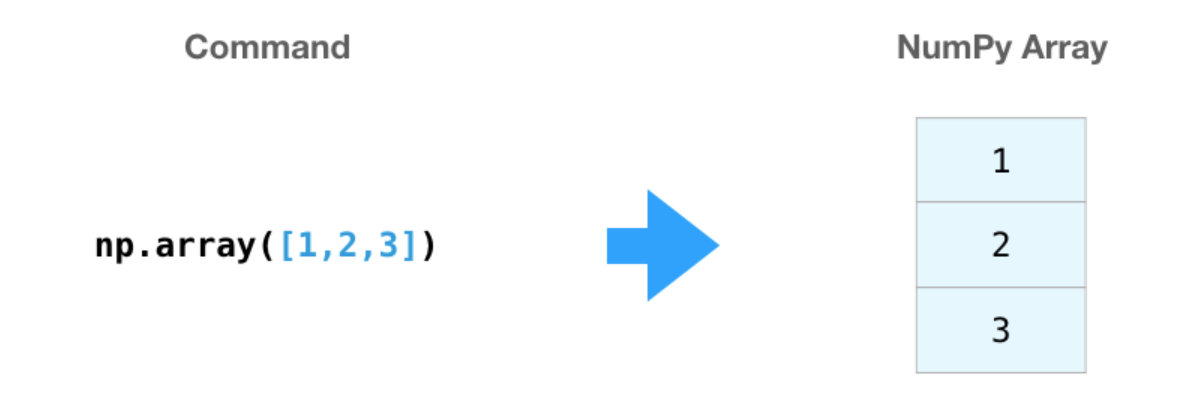

In [6]:
display(Image("./img/2023-10-27-11-02-03.png", width=800, height=400))

In [7]:
import numpy as np

data = np.array([1, 2, 3])
data

array([1, 2, 3])

In [8]:
# ndarray的数据类型,数组只能包含相同类型的数据
data.dtype

dtype('int64')

### 创建ndarray

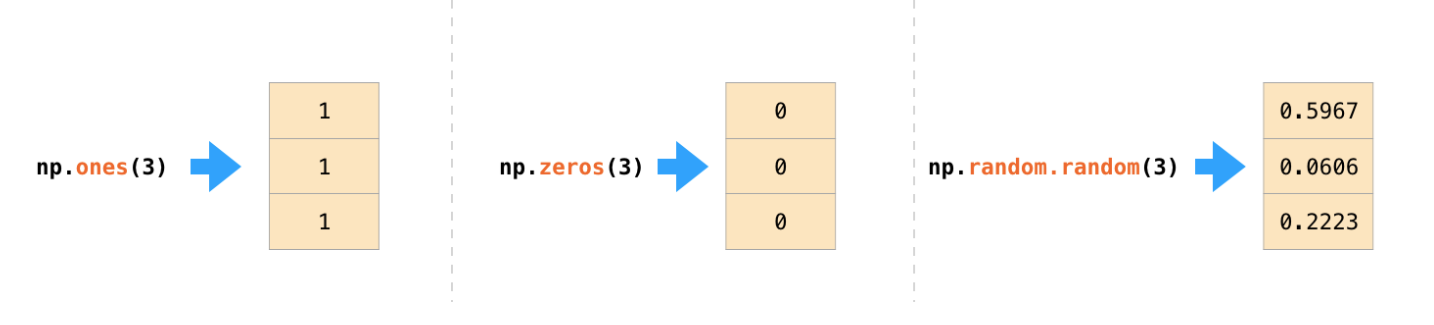

In [9]:
display(Image("./img/2023-10-27-11-06-02.png", width=800, height=400))

In [10]:
# 创建全为1的数组
np.ones(3)

array([1., 1., 1.])

In [11]:
# 创建全为0的数组
np.zeros(3)

array([0., 0., 0.])

In [12]:
# 创建随机数组，长度为3，数值在0-1之间
np.random.random(3)

array([0.92961609, 0.31637555, 0.18391881])

In [13]:
# 类似Python中的range函数
np.arange(10)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [14]:
# 创建形状相同，数值全为1的数组
np.ones_like([1, 2, 3, 4, 5])

array([1, 1, 1, 1, 1])

In [15]:
# 创建形状相同，数值全为0的数组
np.zeros_like([1, 2, 3, 4, 5])

array([0, 0, 0, 0, 0])

In [16]:
# 使用lambda函数创建一个3*3的矩阵, 矩阵的元素的值为i+j
np.fromfunction(lambda i, j: i + j, (3, 3))

array([[0., 1., 2.],
       [1., 2., 3.],
       [2., 3., 4.]])

### 算术运算

`Numpy`中的算术运算可以利用广播（broadcasting）的特性，使得运算自动应用到数组中的所有元素。

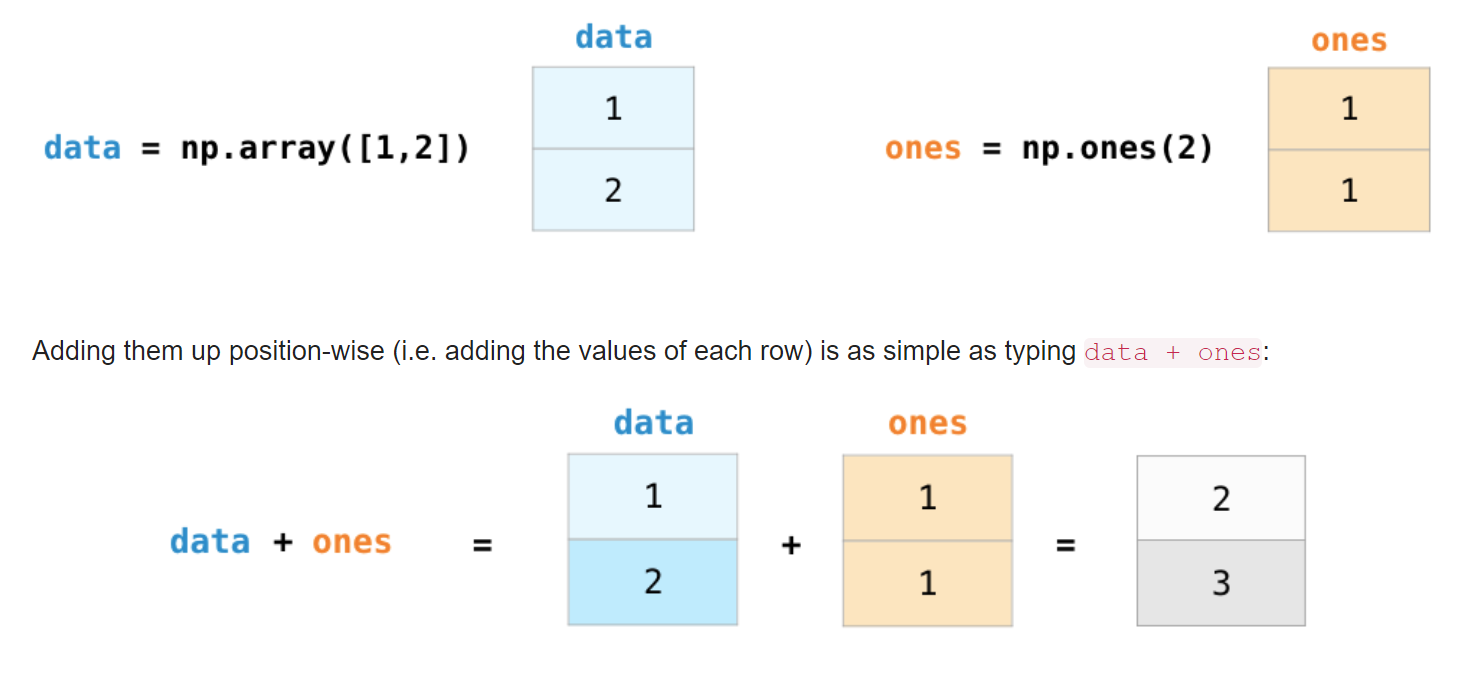

In [17]:
display(Image("./img/2023-10-27-11-16-15.png", width=800, height=600))

In [18]:
import numpy as np
data = np.array([1, 2, 3])
ones = np.ones_like(data)
data + ones

array([2, 3, 4])

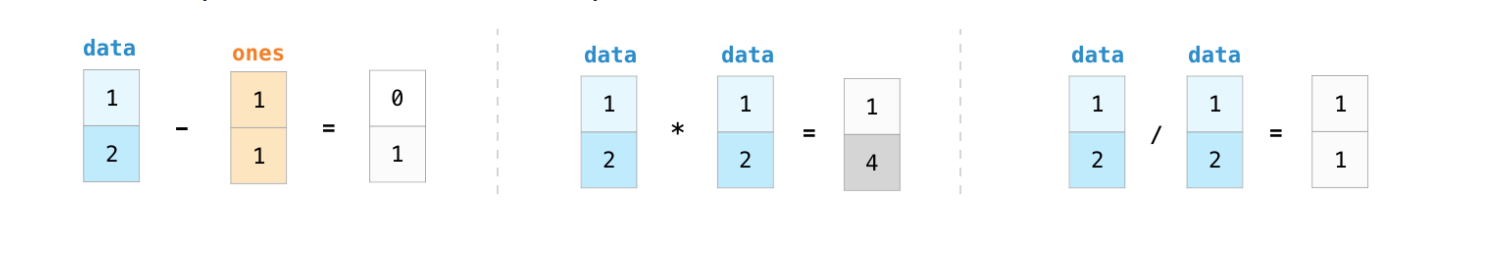

In [19]:
# 其他运算
display(Image("./img/2023-10-27-11-18-34.png", width=800, height=400))

In [20]:
data - ones

array([0, 1, 2])

In [21]:
data * data

array([1, 4, 9])

In [22]:
data / data

array([1., 1., 1.])

In [23]:
data = np.array([2, 3])
print(data)
data ** data

[2 3]


array([ 4, 27])

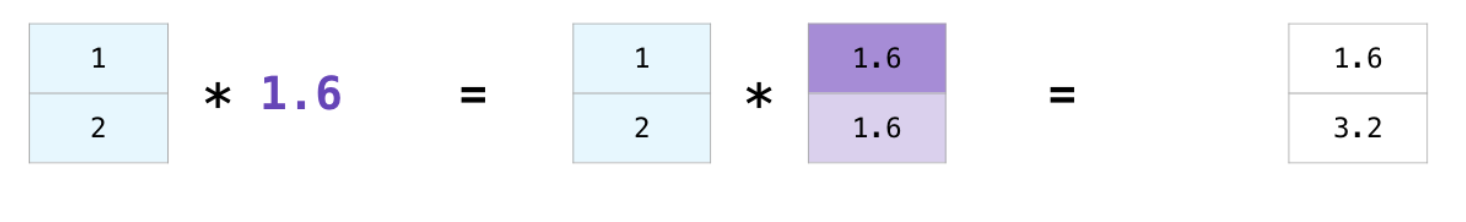

In [24]:
# 数组乘以一个标量
display(Image("./img/2023-10-27-11-20-07.png", width=800, height=400))

In [25]:
data = np.array([1, 2])
data * 1.6

array([1.6, 3.2])

如果想要对数列进行四则混合运算或者更复杂的操作，可以使用`lambda`函数对数列进行向量化操作。例如要对数列中所有的元素`x`进行运算： `x ** 2 + 1`。

In [26]:
arr = np.arange(5)
(lambda x: x ** 2 + 1)(arr)

array([ 1,  2,  5, 10, 17])

### 习题一

完成下面的函数代码:
- 输入参数为整数n, 函数要求创建三个长度为n的一维numpy数列A,B,C和D;
- 数列A中的元素最大为n-1，请使用`np.arange`函数创建数列A；
- 数列B的元素全是n，请使用`np.ones`或者`np.ones_like`函数创建数列B；
- C的元素全是0，请使用`np.zeros_like`函数创建数列C；
- 最后返回数列A，B，C以及他们的和D。
- 注意不要使用循环语句遍历数列。

In [27]:
# UNQ_C1 (UNIQUE CELL IDENTIFIER, DO NOT EDIT)
# GRADED FUNCTION: create_and_add_arrays

def create_and_add_arrays(n: int):
    """创建numpy数组并相加"""

    # 大约需要4行代码，注意不要使用循环

    # 你编写的代码从这里开始
    A = ... # 创建数列A: (0, 1, 2, ... , n-1), 要使用np.arange函数
    B = ... # 创建数列B，要使用np.ones_like函数
    C = ... # 创建数列C，要使用np.zeros_like函数
    D = ... # 创建数列D，等于前面3个数列的和

    # 你编写的代码到这里结束
    return A, B, C, D

In [28]:
# 测试习题1
testsuite2.test_create_and_add_arrays(create_and_add_arrays)

测试失败 test_create_and_add_arrays: 
Arrays are not equal
数组A不符合预期
Mismatched elements: 4 / 4 (100%)
 ACTUAL: array(Ellipsis, dtype=object)
 DESIRED: array([0, 1, 2, 3])


### 索引和切片

numpy数组的索引和切片和Python的列表类似，但是有一些特殊的地方。

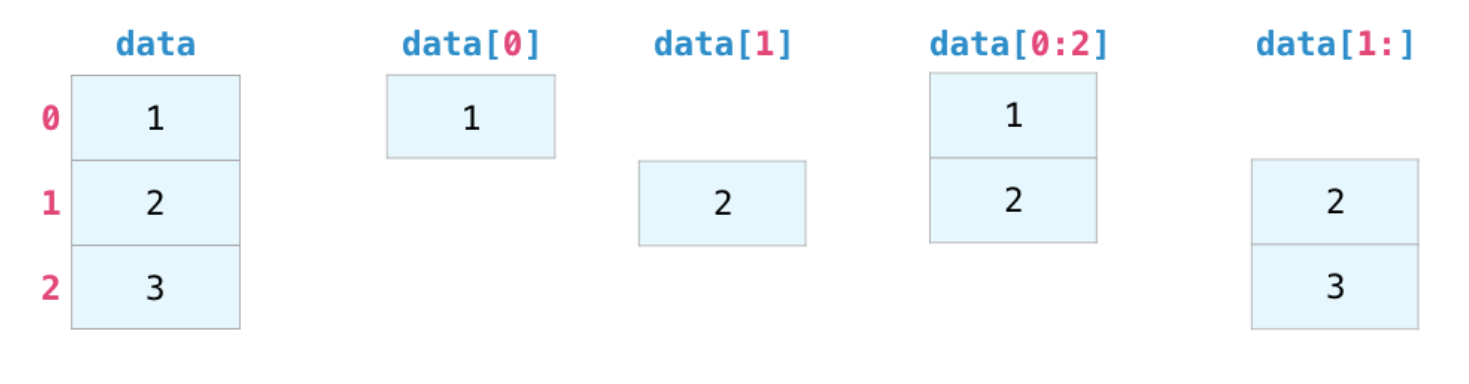

In [29]:
display(Image("./img/2023-10-27-11-35-38.png", width=800, height=400))

In [30]:
data = np.array([1, 2, 3])
print(data[0])
print(data[-1])
print(data[0:2])
print(data[1:])
print(data[::-1]) # 倒序

1
3
[1 2]
[2 3]
[3 2 1]


### 一维数据的聚合

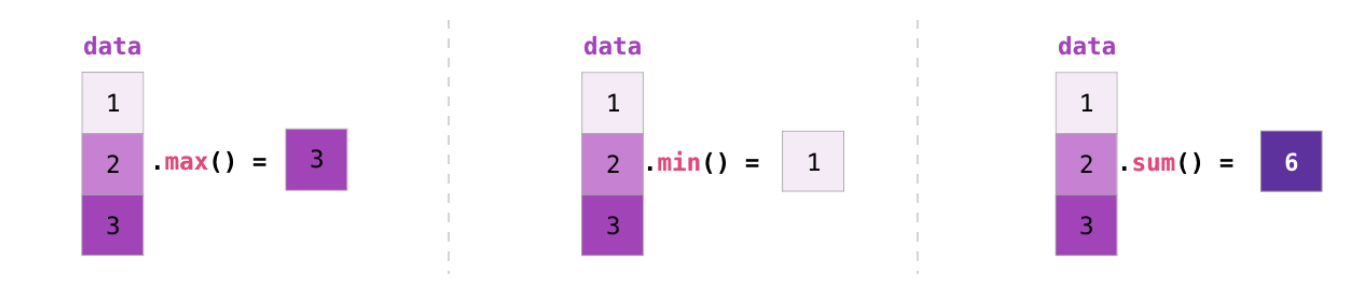

In [31]:
display(Image("./img/2023-10-27-11-40-03.png", width=800, height=400))

In [32]:
data = np.array([1, 2, 3])
print(data)

# 求最大值、最小值、求和
print(data.max())
print(data.min())
print(data.sum())

# 求均值、标准差
print(data.mean())
print(data.std())

# 求最大值、最小值的索引
print(data.argmax())   # 返回2，即最大值3的索引
print(data.argmin())   # 返回0，即最小值1的索引

# 排序
data = np.array([9, 3, 5, 7, 1, 2])
data.sort()
print(data)

[1 2 3]
3
1
6
2.0
0.816496580927726
2
0
[1 2 3 5 7 9]


### 习题二

函数的输入是两个一维numpy数列A和B(数列都不为空)，返回数列A中的最大值与和数列B的最小值的乘积。请注意不要使用循环语句遍历数列。

In [33]:
# UNQ_C2 (UNIQUE CELL IDENTIFIER, DO NOT EDIT)
# GRADED FUNCTION: multiply_max_min

def multiply_max_min(A, B):
    """返回数列A最大值和数列B最小值的乘积"""
    # 只需要1行代码
    # 你编写的代码从这里开始
    result = ...

    # 你编写的代码到这里结束
    return result

In [34]:
# 测试习题2
testsuite2.test_multiply_max_min(multiply_max_min)

测试失败 test_multiply_max_min: 


### 二维矩阵

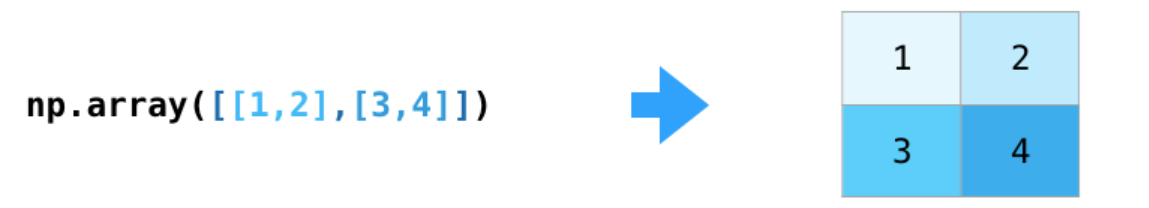

In [35]:
display(Image("./img/2023-10-27-11-52-59.png", width=800, height=400))

In [36]:
data = np.array([[1, 2], [3, 4]])
data

array([[1, 2],
       [3, 4]])

![创建多维数据](./img/2023-10-27-11-54-20.png)

In [37]:
print(np.ones((3,2)))

[[1. 1.]
 [1. 1.]
 [1. 1.]]


In [38]:
print(np.zeros((3,2)))

[[0. 0.]
 [0. 0.]
 [0. 0.]]


In [39]:
print(np.random.random((3,2)))

[[0.20456028 0.56772503]
 [0.5955447  0.96451452]
 [0.6531771  0.74890664]]


In [40]:
np.diag([1, 2, 3])

array([[1, 0, 0],
       [0, 2, 0],
       [0, 0, 3]])

In [41]:
# 单元矩阵
np.eye(3)

array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])

### 二维矩阵的索引和切片

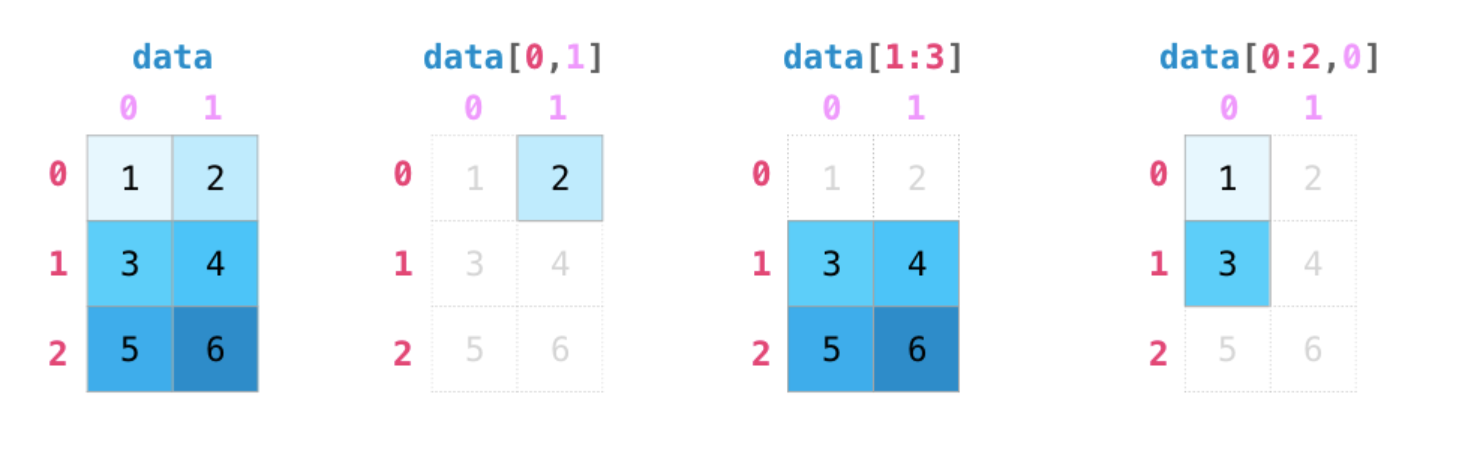

In [42]:
display(Image("./img/2023-10-27-12-08-39.png", width=800, height=400))

In [43]:
data = np.array([[1, 2, 3], [3, 4, 7], [5, 6, 9]])
print(data)

# 使用行索引和列索引选择到一个元素
print(data[0, 1])

# 使用行索引的切片
print(data[1:3,:])

# 行索引和列索引同时使用切片
print(data[0:2, ::2])

[[1 2 3]
 [3 4 7]
 [5 6 9]]
2
[[3 4 7]
 [5 6 9]]
[[1 3]
 [3 7]]


### 习题三

已知一个二维的numpy矩阵stocks，其中每一行代表若干只股票某天的收盘价格，每一列代表某只股票连续若干天的价格。请完成函数代码，获取每只股票从第一天开始每三天的价格。请注意不要使用循环语句遍历矩阵。

例如：
```
stocks = np.array([[1,2,3,4,5,6,7,8,9,10],
                    [11,12,13,14,15,16,17,18,19,20],
                    [21,22,23,24,25,26,27,28,29,30],
                    [31,32,33,34,35,36,37,38,39,40]])       
``` 
返回结果为：
```
np.array([[1,2,3,4,5,6,7,8,9,10],
            [31,32,33,34,35,36,37,38,39,40]]) 
```

In [44]:
# UNQ_C3 (UNIQUE CELL IDENTIFIER, DO NOT EDIT)
# GRADED FUNCTION: get_stocks_price

def get_stocks_price(stocks):
    """获取股票的收盘价"""
    # 只需要1行代码, 请使用切片
    # 你编写的代码从这里开始
    result = ...

    # 你编写的代码到这里结束
    return result

In [45]:
# 测试习题3
testsuite2.test_get_stocks_price(get_stocks_price)

测试失败 test_get_stocks_price: 
Arrays are not equal

Mismatched elements: 20 / 20 (100%)
 ACTUAL: array(Ellipsis, dtype=object)
 DESIRED: array([[ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10],
       [31, 32, 33, 34, 35, 36, 37, 38, 39, 40]])


### 矩阵运算🧮

二维的`Numpy`矩阵同样具有广播(Broadcasting)特性，稍微不同的是，`Numpy`会根据运算的矩阵的形状将运算自动广播到行、列或者每个元素上。

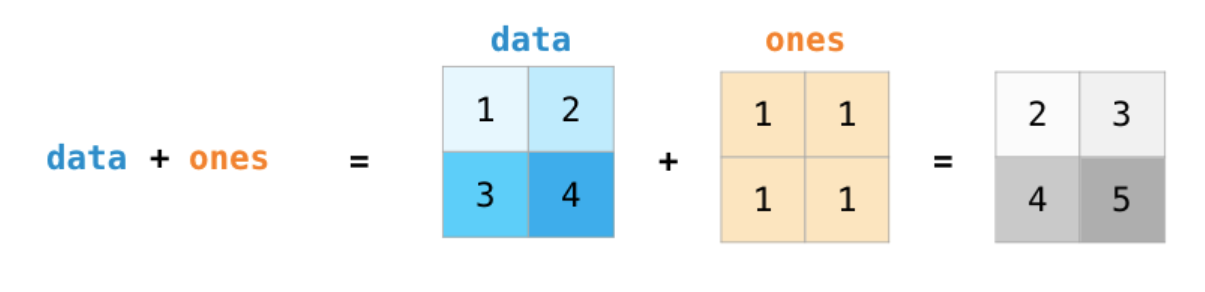

In [46]:
display(Image("./img/2023-10-27-12-03-47.png", width=800, height=400))

In [47]:
data = np.array([[1, 2], [3, 4]])
ones = np.ones([2, 2])
data + ones

array([[2., 3.],
       [4., 5.]])

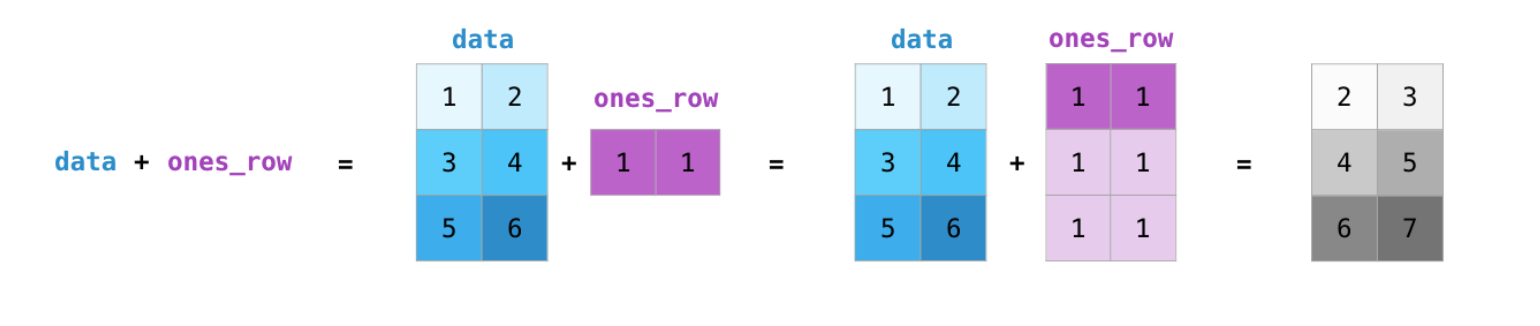

In [48]:
display(Image("./img/2023-10-27-12-04-55.png", width=800, height=400))

In [49]:
data = np.array([[1, 2], [3, 4], [5, 6]])
# 按行相加，广播到行
ones_row = np.ones([1, 1])
data + ones_row

array([[2., 3.],
       [4., 5.],
       [6., 7.]])

In [50]:
print("data:\n", data)

# 按列相加， 广播到列
column_data = np.array([10, 20, 30])

# 转换为列向量
print("column:\n", column_data[:, np.newaxis])

data + column_data[:, np.newaxis]

data:
 [[1 2]
 [3 4]
 [5 6]]
column:
 [[10]
 [20]
 [30]]


array([[11, 12],
       [23, 24],
       [35, 36]])

### 矩阵的转置和变形

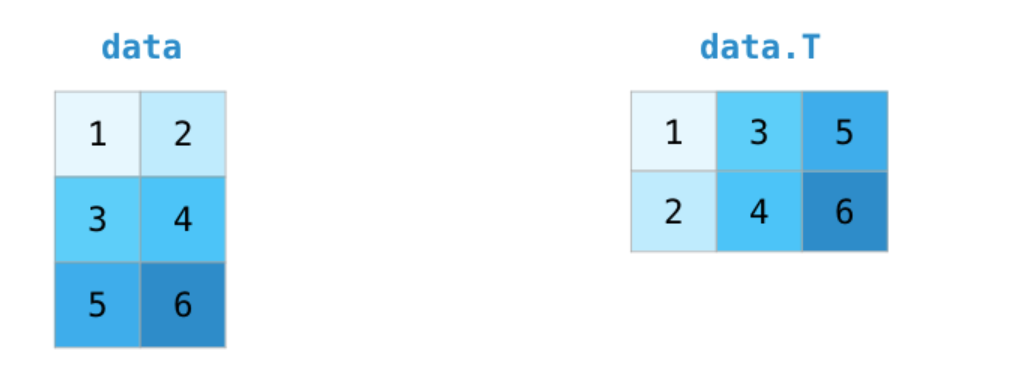

In [51]:
display(Image("./img/2023-10-27-13-40-49.png", width=800, height=400))

In [52]:
# 矩阵转置
data = np.array([[1, 2],
                    [3, 4],
                    [5, 6]])
data.T

array([[1, 3, 5],
       [2, 4, 6]])

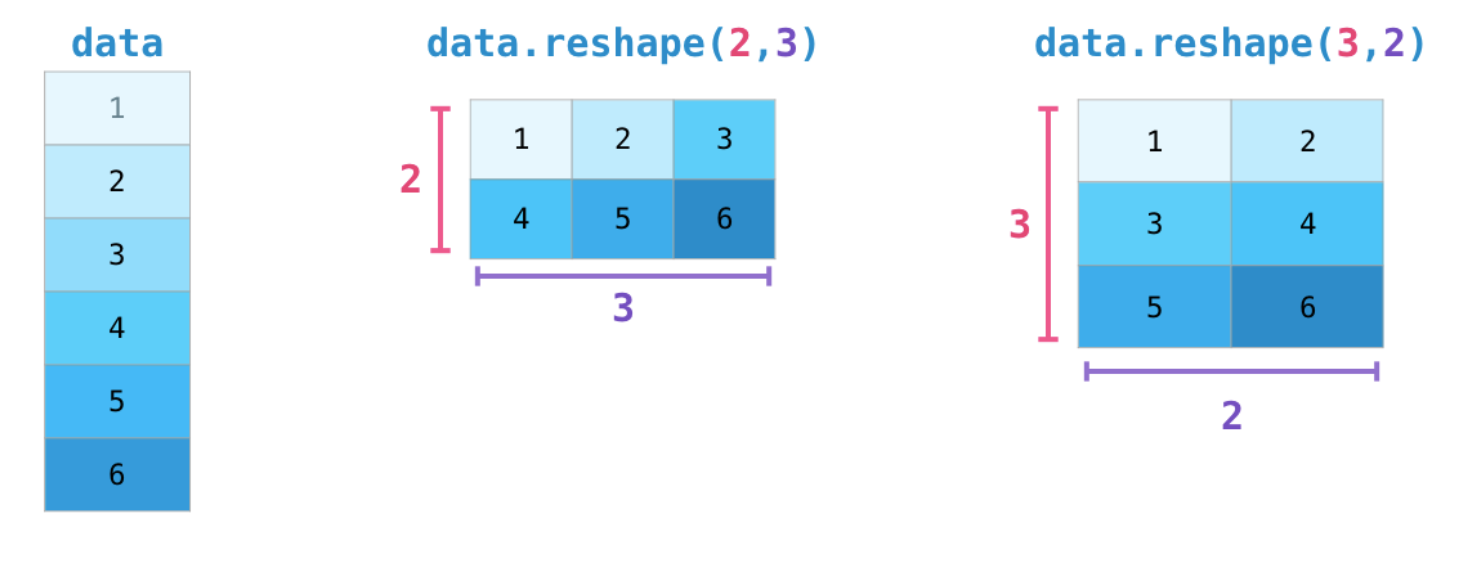

In [53]:
display(Image("./img/2023-10-27-13-42-39.png", width=800, height=400))

In [54]:
data = np.arange(1, 7)
print(data)
print(data.reshape(2, 3))  # 转换成2 * 3的矩阵
print(data.reshape(3, 2))
print(data.reshape(6, 1))  # 转换成6 * 1的矩阵
print(data.reshape(6,))    # 转换成一维的 1 * 6 的数列

[1 2 3 4 5 6]
[[1 2 3]
 [4 5 6]]
[[1 2]
 [3 4]
 [5 6]]
[[1]
 [2]
 [3]
 [4]
 [5]
 [6]]
[1 2 3 4 5 6]


In [55]:
data = np.arange(1, 7)
print(data)

# 在reshape函数中，如果指定一个维度为-1，那么reshape函数会自动计算这个维度的大小
print(data.reshape(2, -1))  # 推算出第二个维度应该为3，转换成2 * 3的矩阵
print(data.reshape(-1, 2))  # 推算出第一个维度应该为3，转换成3 * 2的矩阵
print(data.reshape(-1,))    # 推算出第一个维度应该为6，转换成一维的 1 * 6 的数列

[1 2 3 4 5 6]
[[1 2 3]
 [4 5 6]]
[[1 2]
 [3 4]
 [5 6]]
[1 2 3 4 5 6]


### 习题四

下面的函数输入是二维矩阵`A`, 要求函数获取到`A`的形状`shape`，然后将`A`转换成一维数列B，最后将数列B中的元素逆序排列后,函数返回`shape`和逆序后的数列`B`。请注意不要使用循环语句遍历矩阵。

例如：
```python
A = np.array([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9],
])
```

返回值应该如下：
```python
((3, 3), array([9, 8, 7, 6, 5, 4, 3, 2, 1]))
```

In [56]:
# UNQ_C4 (UNIQUE CELL IDENTIFIER, DO NOT EDIT)
# GRADED FUNCTION: reshape_and_reverse

def reshape_and_reverse(A):
    """获取矩阵形状，变形矩阵，逆序数列"""

    # 大约需要2-3行代码
    # 你编写的代码从这里开始
    shape = ...    # 获取矩阵A的形状
    B = ...        # 将矩阵A转换成数列B
    B = ...        # 将数列B逆序
    # 你编写的代码到这里结束
    return shape, B

In [57]:
M = np.arange(1, 10)
reshape_and_reverse(M.reshape(3,3))
# 输出的结果应该是： ((3, 3), array([9, 8, 7, 6, 5, 4, 3, 2, 1]))

((3, 3), array([9, 8, 7, 6, 5, 4, 3, 2, 1]))

In [58]:
# 测试习题4
testsuite2.test_reshape_and_reverse(reshape_and_reverse)

恭喜你通过了习题四 test_reshape_and_reverse 测试。1/4


### 线性代数

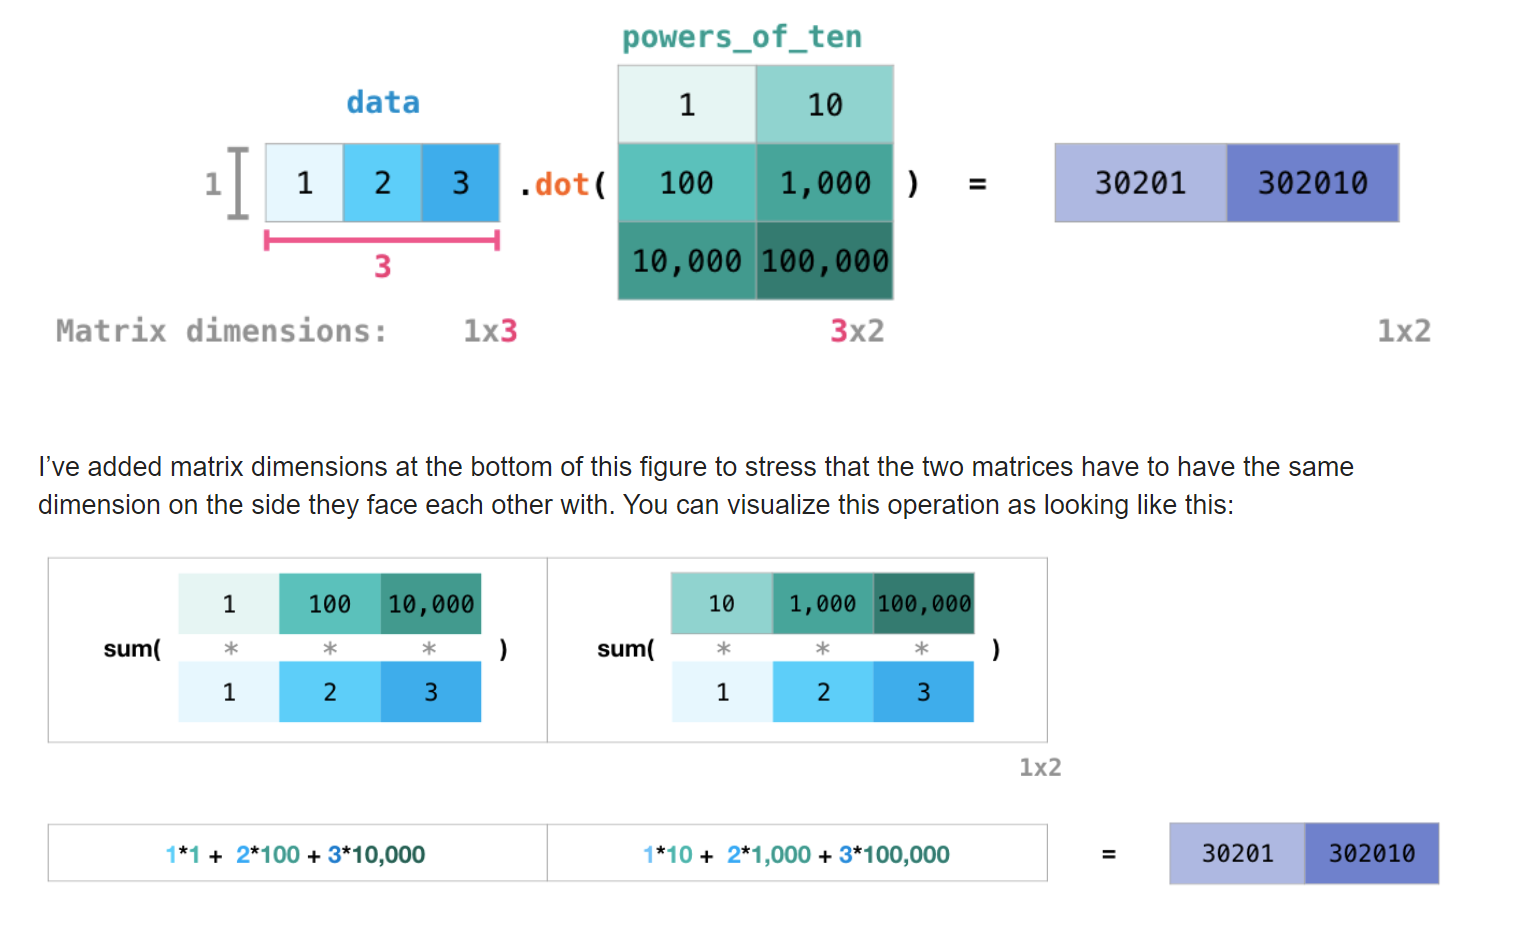

In [59]:
display(Image("./img/2023-10-27-13-11-55.png", width=600, height=400))

In [60]:
# 点乘
data = np.array([1, 2, 3])
power_of_tens = np.array([[1, 10],
                        [100, 1000],
                        [10000, 100000]])
data.dot(power_of_tens)

array([ 30201, 302010])

In [61]:
# 二维矩阵也可以使用@符号进行点乘乘法,
# 但是更高维的数列则必须使用np.dot()来进行点乘
data @ power_of_tens   # 相当于调用了np.matmul()函数

array([ 30201, 302010])

In [62]:
# 矩阵求逆
data = np.array([[1, 2], [3, 4]])
np.linalg.inv(data)

array([[-2. ,  1. ],
       [ 1.5, -0.5]])

In [63]:
# 矩阵行列式
np.linalg.det(data)

np.float64(-2.0000000000000004)

### 习题五

下面的函数输入参数是两个二维矩阵`A`和`B`，要求函数计算`A`和`B`的矩阵乘积，将乘积结果的矩阵(乘积结果不是奇异矩阵并且可逆)求逆后返回结果。请注意不要使用循环语句遍历矩阵。

例如：
```python
A = np.array([
    [1, 2],
    [3, 4]
])

B = np.array([
    [1, 0],
    [0, 1],
])
```

返回值应该如下：
```python
array([[-2. ,  1. ],
       [ 1.5, -0.5]])
```

In [64]:
# UNQ_C5 (UNIQUE CELL IDENTIFIER, DO NOT EDIT)
# GRADED FUNCTION: matrix_product_and_inverse

def matrix_product_and_inverse(A, B):
    """
    计算矩阵A和B的乘积,然后求逆
    """

    # 大约需要2行代码
    # 你编写的代码从这里开始
    product = ...    # 计算矩阵A和B的乘积
    inverse = ...    # 矩阵求逆
    # 你编写的代码到这里结束

    return inverse

In [65]:
m1 = np.array([
    [1, 2],
    [3, 4]
])
m2 = np.eye(2)
matrix_product_and_inverse(m1, m2)
# 输出结果应该是： array([[-2. ,  1. ],  [ 1.5, -0.5]])

Ellipsis

In [66]:
# 测试习题5
testsuite2.test_matrix_product_and_inverse(matrix_product_and_inverse)

测试失败 test_matrix_product_and_inverse: unsupported operand type(s) for -: 'ellipsis' and 'float'


### 矩阵的聚合

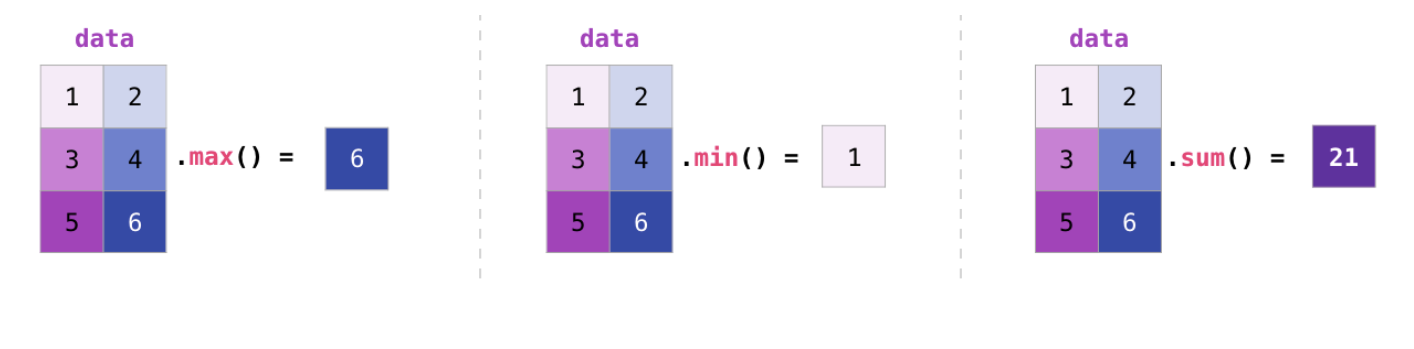

In [67]:
display(Image("./img/2023-10-27-13-33-54.png", width=800, height=400))

In [68]:
data = np.array([[1, 2],[5, 3], [4, 6]])
print(data.max())
print(data.min())
print(data.sum())

6
1
21


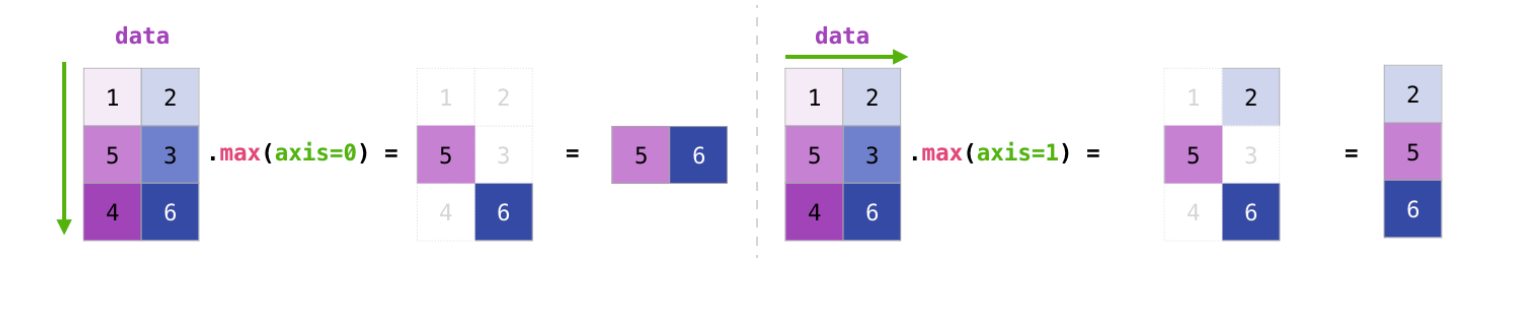

In [69]:
display(Image("./img/2023-10-27-13-34-55.png", width=800, height=400))

In [70]:
print(data)
print('求每列最大值:',data.max(axis=0))

print('求每行最大值:',data.max(axis=1))

print('计算每列的和:',data.sum(axis=0))

print('计算每行的和:',data.sum(axis=1))

print('计算每列的平均值:', data.mean(axis=0))

[[1 2]
 [5 3]
 [4 6]]
求每列最大值: [5 6]
求每行最大值: [2 5 6]
计算每列的和: [10 11]
计算每行的和: [ 3  8 10]
计算每列的平均值: [3.33333333 3.66666667]


### 习题六

下面函数的输入参数是二维矩阵，存储了某班级学生的各科的成绩，每一行代表一个学生的各科成绩，每一列代表一门课程的所有学生的成绩。要求函数计算每门课程的平均成绩和每个学生的总成绩。请注意不要使用循环语句遍历矩阵。

例如：
```python
scores = np.array([
    [80, 90, 85],
    [70, 60, 65],
    [90, 80, 85],
    [85, 75, 80],
    [60, 70, 75],
])
```

返回值应该如下：
```python
(array([77., 75., 78.]), array([255., 195., 255., 240., 205.]))
```

In [71]:
# UNQ_C6 (UNIQUE CELL IDENTIFIER, DO NOT EDIT)
# GRADED FUNCTION: compute_scores

def compute_scores(scores):
    """
    计算每个学生的总分和每门科目的平均分
    """

    # 大约需要2行代码
    # 你编写的代码从这里开始
    mean = ...     # 计算每个科目的平均分
    total = ...    # 计算每个学生的总分

    # 你编写的代码到这里结束

    return  mean, total

In [72]:
scores = np.array([
    [80, 90, 85],
    [70, 60, 65],
    [90, 80, 85],
    [85, 75, 80],
    [60, 70, 75],
])
compute_scores(scores)
# 输出结果应该是： (array([77. , 75. , 78.]), array([255, 195, 255, 240, 205]))

(Ellipsis, Ellipsis)

In [73]:
# 测试习题6
testsuite2.test_compute_scores(compute_scores)

测试失败 test_compute_scores: unsupported operand type(s) for -: 'ellipsis' and 'float'


### 在数列操作中使用条件逻辑

`numpy.where`语句是向量化的`if else`语句

In [74]:
xarr = np.array([1.1, 1.2, 1.3, 1.4, 1.5])
yarr = np.array([2.1, 2.2, 2.3, 2.4, 2.5])
cond = np.array([True, False, True, True, False])

如果条件数列`cond`的元素为`True`，我们就取xarr中的元素，如果为`False`，我们就取yarr中的元素。

In [75]:
# 非向量化的方法
# 这样速度会很慢, 而且也不适用于高维度的数据
result = [( x if c else y)
          for x,y,c in zip(xarr, yarr, cond)]
result

[np.float64(1.1),
 np.float64(2.2),
 np.float64(1.3),
 np.float64(1.4),
 np.float64(2.5)]

In [76]:
# 向量化的方法
# 速度更快，并且适用于多维向量
result = np.where(cond, xarr, yarr)
result

array([1.1, 2.2, 1.3, 1.4, 2.5])

In [77]:
# np.where语句的第二个和第三个参数也可以是标量
arr = np.arange(5)
print(arr > 2)
np.where(arr > 2,  1,  -1)

[False False False  True  True]


array([-1, -1, -1,  1,  1])

### 习题七

完成下面的函数，函数输入是：
- scores: 考试成绩的数列
- threshold: 考试成绩及格分数（可选参数）

函数返回：
- pass_status: 考试成绩通过与否的布尔数列, True表示通过, False表示不通过
- grades: numpy数组, 包含成绩等级字符串 ('A', 'B', 'C', 'D', 'F')，A(>=90), B(>=80), C(>=70), D(>=60), F(<60)
- bonus_scores: numpy数组, 优秀学生(>=90分)获得5分奖励, 其他学生分数不变

习题要求：
- 要求使用向量化操作，不能使用循环语句
- 要求使用`np.where`语句，不能使用`if else`语句

In [78]:
# UNQ_C7 (UNIQUE CELL IDENTIFIER, DO NOT EDIT)
# GRADED FUNCTION: process_exam_results

def process_exam_results(scores, pass_threshold=60):
    """
    处理考试成绩，根据分数判断通过/不通过状态和等级

    参数:
    scores: numpy数组, 包含学生成绩
    pass_threshold: 及格线, 默认为60分

    返回:
    pass_status: numpy数组, True表示通过, False表示不通过
    grades: numpy数组, 包含等级字符串 ('A', 'B', 'C', 'D', 'F')
    bonus_scores: numpy数组, 优秀学生(>=90分)获得5分奖励, 其他学生分数不变
    """

    # 大约需要3-6行代码，必须使用np.where函数
    # 你编写的代码从这里开始
    pass_status = ...
    grades = ...
    bonus_scores = ...

    # 你编写的代码到这里结束
    return pass_status, grades, bonus_scores

In [79]:
scores = np.array([[90, 80, 70], [80, 80, 70], [70, 60, 50]])
process_exam_results(scores)
# 预期结果为：
# (array([[ True,  True,  True],
#         [ True,  True,  True],
#         [ True,  True, False]]),
#  array([['A', 'B', 'C'],
#         ['B', 'B', 'C'],
#         ['C', 'C', 'F']], dtype='<U1'),
#  array([[95, 80, 70],
#         [80, 80, 70],
#         [70, 60, 50]]))

(Ellipsis, Ellipsis, Ellipsis)

In [80]:
# 测试习题7
testsuite2.test_process_exam_results(process_exam_results)

测试失败 test_process_exam_results: 
Arrays are not equal
通过状态判断错误
Mismatched elements: 10 / 10 (100%)
 ACTUAL: array(Ellipsis, dtype=object)
 DESIRED: array([ True,  True,  True,  True, False, False,  True,  True, False,
        True])


### 更高维的数组（tensor--张量）

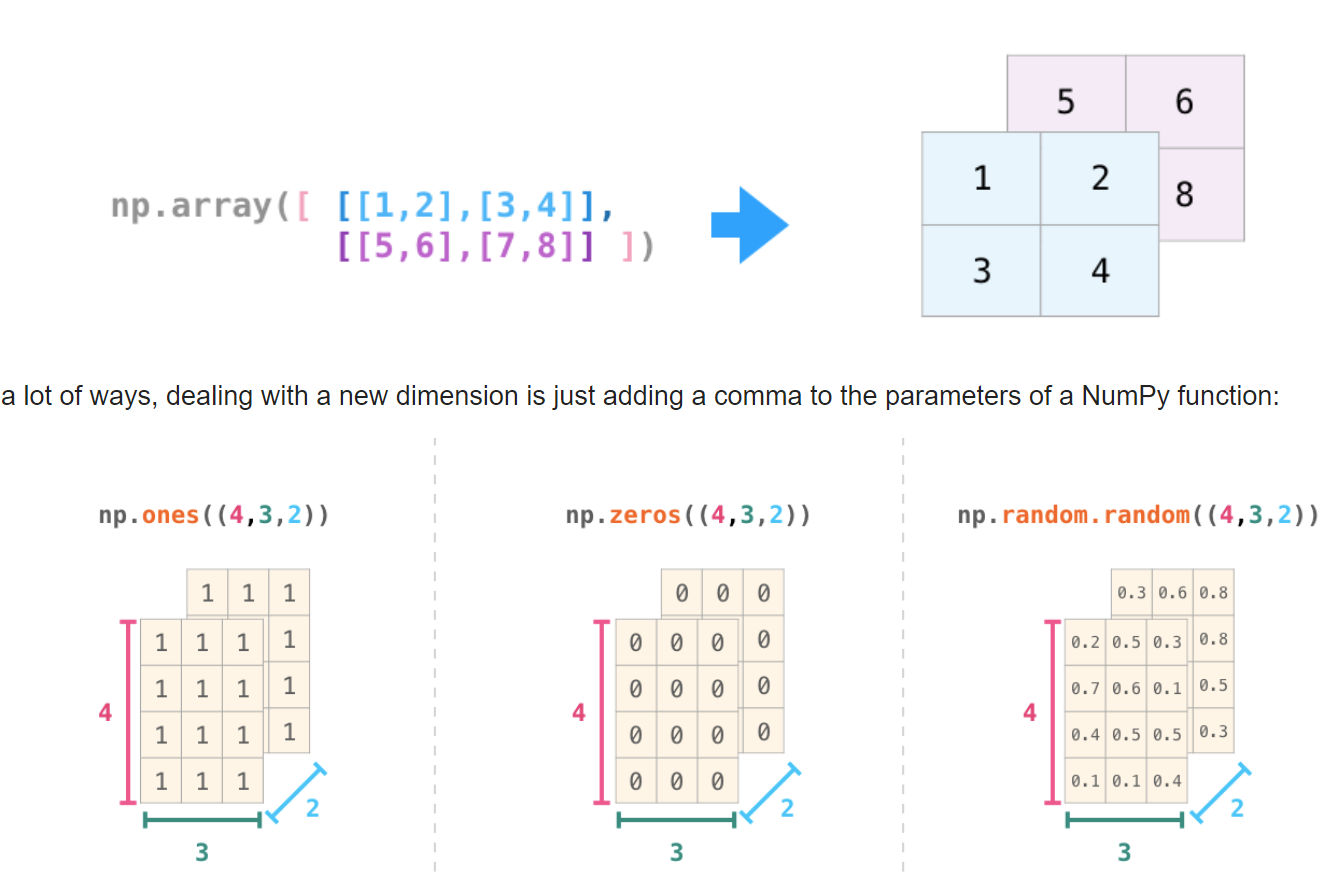

In [81]:
display(Image("./img/2023-10-27-14-11-21.png", width=800, height=400))

In [82]:
np.arange(1,9).reshape(2, 2, 2)

array([[[1, 2],
        [3, 4]],

       [[5, 6],
        [7, 8]]])

In [83]:
print(np.ones((4, 3, 2)))
print(np.zeros((4, 3, 2)))
print(np.random.random((4, 3, 2)))

[[[1. 1.]
  [1. 1.]
  [1. 1.]]

 [[1. 1.]
  [1. 1.]
  [1. 1.]]

 [[1. 1.]
  [1. 1.]
  [1. 1.]]

 [[1. 1.]
  [1. 1.]
  [1. 1.]]]
[[[0. 0.]
  [0. 0.]
  [0. 0.]]

 [[0. 0.]
  [0. 0.]
  [0. 0.]]

 [[0. 0.]
  [0. 0.]
  [0. 0.]]

 [[0. 0.]
  [0. 0.]
  [0. 0.]]]
[[[0.65356987 0.74771481]
  [0.96130674 0.0083883 ]
  [0.10644438 0.29870371]]

 [[0.65641118 0.80981255]
  [0.87217591 0.9646476 ]
  [0.72368535 0.64247533]]

 [[0.71745362 0.46759901]
  [0.32558468 0.43964461]
  [0.72968908 0.99401459]]

 [[0.67687371 0.79082252]
  [0.17091426 0.02684928]
  [0.80037024 0.90372254]]]


### Numpy的应用

- 线性代数，统计学方面的运算
- 表示各种类型的数据：图像，音频，文本
- 用于机器学习和深度学习的算法

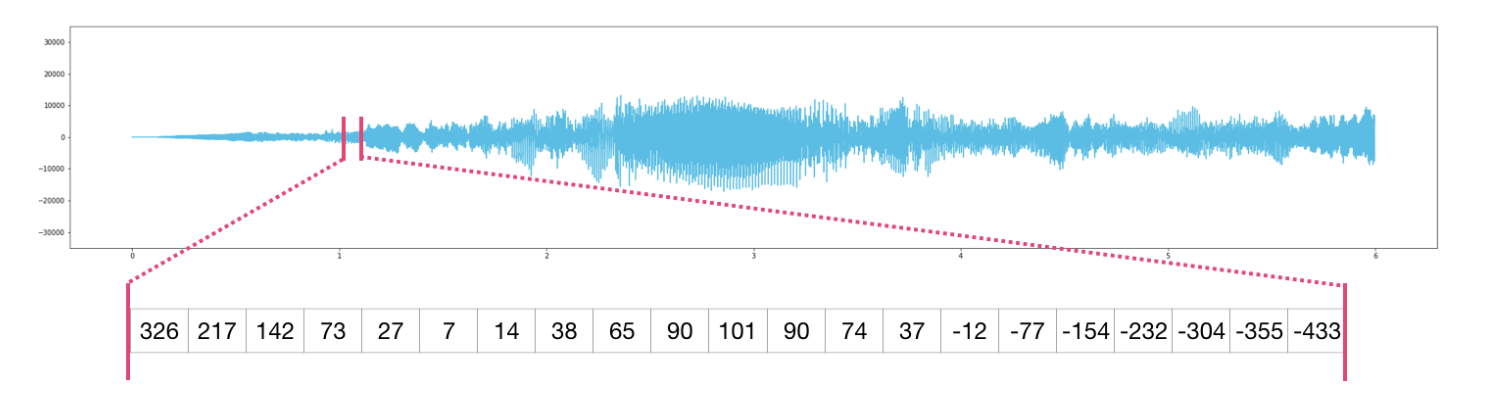

In [84]:
display(Image("./img/2023-10-27-14-19-04.png", width=800, height=800))

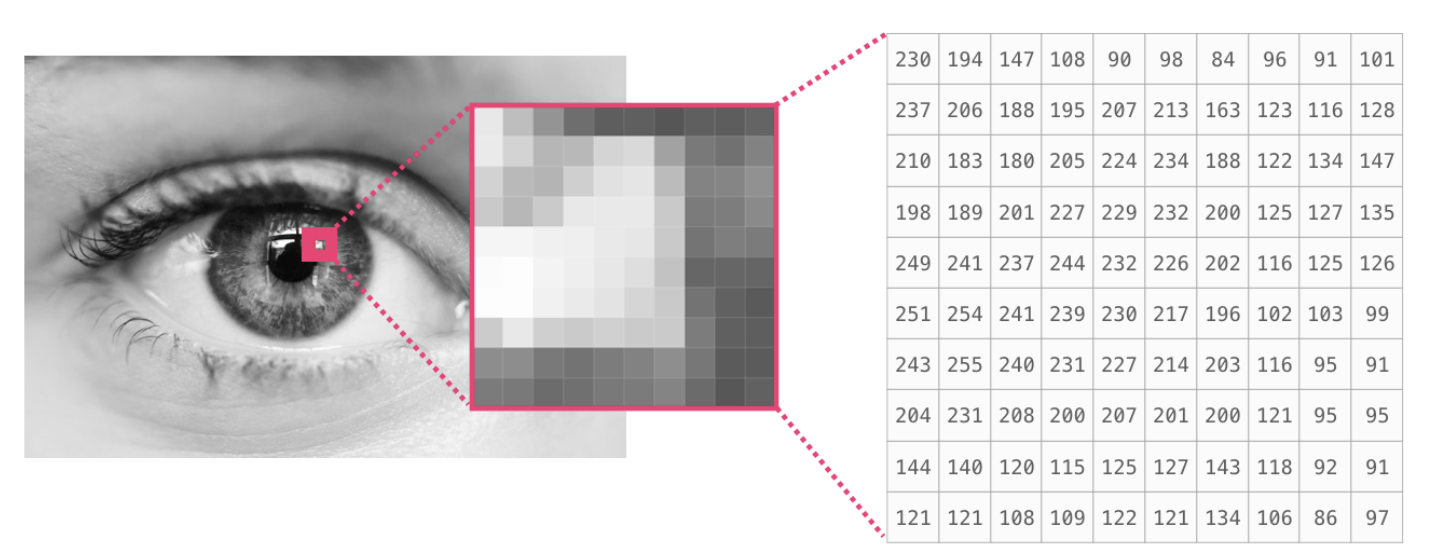

In [85]:
display(Image("./img/2023-10-27-14-20-34.png", width=800, height=800))

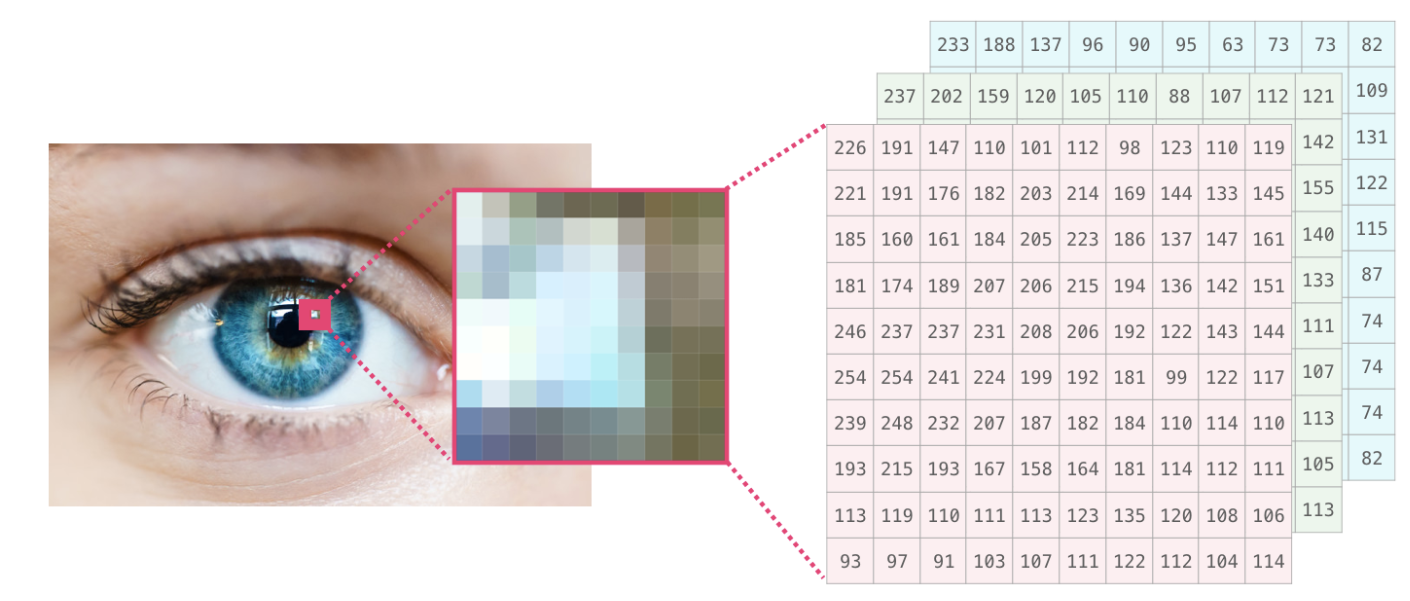

In [86]:
display(Image("./img/2023-10-27-14-21-52.png", width=800, height=800))

## Pandas🐼

### `Pandas`数据结构

`Pandas`是基于`Numpy`的一个数据处理库，提供了两种数据结构：`Series`和`DataFrame`。

- `Series`是一个一维的数据结构，类似于`Numpy`中的一维数组，不同的是`Series`可以有非整数的索引（被称作标签），可以通过标签来访问数据。
- `DataFrame`是一个二维的数据结构，类似于电子表格或者SQL表，可以存储多种类型的数据，可以通过行和列的索引(可以不是整数)来访问数据, `DataFrame`可以看作是由多个`Series`组成的。

### 加载数据

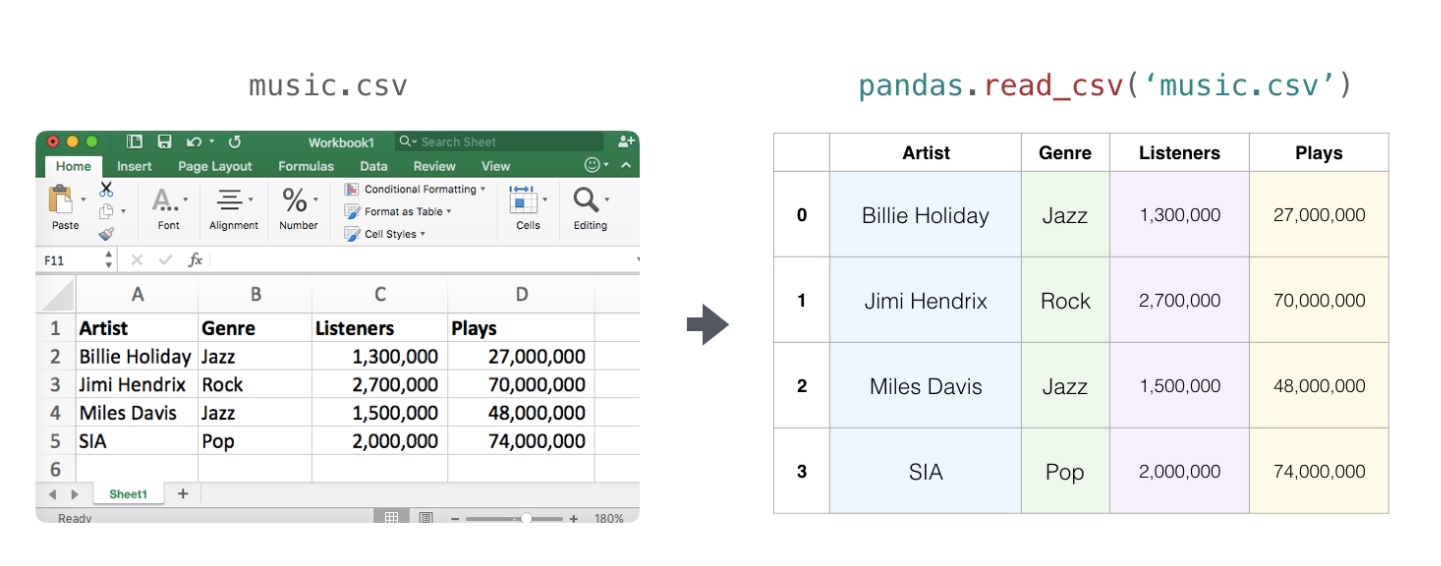

In [87]:
display(Image("./img/2023-10-31-07-58-44.png", width=800, height=600))

In [88]:
import pandas as pd

# 读取csv文件,得到二维结构的数据： DataFrame
df = pd.read_csv('./data/music.csv')
df

,Artist,Genre,Listeners,Plays
0,Billie Holiday,Jazz,1300000,27000000
1,Jimi Hendrix,Rock,2700000,70000000
2,Miles Davis,Jazz,1500000,48000000
3,SIA,Pop,2000000,74000000


pandas可以从下面这些来源加载数据：

- CSV
- Excel
- HTML
- JSON
- SQL
- API
- 等等其他

### 选择数据

In [89]:
# 按照列名选择数据
df['Artist']

0    Billie Holiday
1      Jimi Hendrix
2       Miles Davis
3               SIA
Name: Artist, dtype: object

In [90]:
# 选择多列数据
df[['Artist', 'Plays']]

,Artist,Plays
0,Billie Holiday,27000000
1,Jimi Hendrix,70000000
2,Miles Davis,48000000
3,SIA,74000000


In [91]:
# 按照行索引选择数据
df[1:3]

,Artist,Genre,Listeners,Plays
1,Jimi Hendrix,Rock,2700000,70000000
2,Miles Davis,Jazz,1500000,48000000


In [92]:
# 按照行索引和列索引选择数据
df.loc[1:3, ['Artist', 'Plays']]

,Artist,Plays
1,Jimi Hendrix,70000000
2,Miles Davis,48000000
3,SIA,74000000


### 过滤数据

In [93]:
df[df['Genre']=='Jazz']

,Artist,Genre,Listeners,Plays
0,Billie Holiday,Jazz,1300000,27000000
2,Miles Davis,Jazz,1500000,48000000


In [94]:
df[df['Listeners'] > 1800000]

,Artist,Genre,Listeners,Plays
1,Jimi Hendrix,Rock,2700000,70000000
3,SIA,Pop,2000000,74000000


### 处理数据缺失的情况

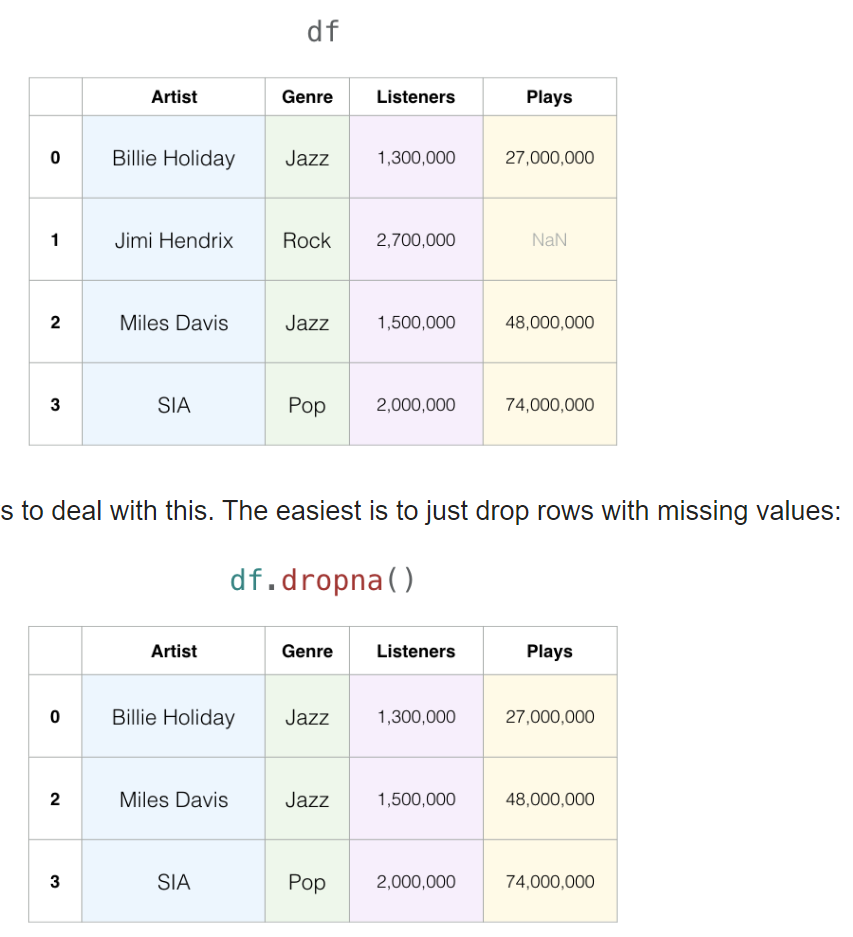

In [95]:
display(Image("./img/2023-10-31-08-20-30.png", width=800, height=600))

In [96]:
df2 = pd.read_csv('./data/music copy.csv')
df2

,Artist,Genre,Listeners,Plays
0,Billie Holiday,Jazz,1300000,27000000.0
1,Jimi Hendrix,Rock,2700000,NaN
2,Miles Davis,Jazz,1500000,48000000.0
3,SIA,Pop,2000000,74000000.0


In [97]:
df2.dropna()

,Artist,Genre,Listeners,Plays
0,Billie Holiday,Jazz,1300000,27000000.0
2,Miles Davis,Jazz,1500000,48000000.0
3,SIA,Pop,2000000,74000000.0


In [98]:
df2.fillna(method='ffill')

/var/folders/d8/95j6qccn647c28sgypwqhjcc0000gn/T/ipykernel_99822/2637084966.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df2.fillna(method='ffill')


,Artist,Genre,Listeners,Plays
0,Billie Holiday,Jazz,1300000,27000000.0
1,Jimi Hendrix,Rock,2700000,27000000.0
2,Miles Davis,Jazz,1500000,48000000.0
3,SIA,Pop,2000000,74000000.0


### Grouping

In [99]:
df.groupby('Genre').sum()

,Artist,Listeners,Plays
Genre,,,
Jazz,Billie HolidayMiles Davis,2800000,75000000
Pop,SIA,2000000,74000000
Rock,Jimi Hendrix,2700000,70000000


### 创建新的列

In [100]:
# 计算每个歌手的平均播放量
df['Avg Plays'] = df['Plays'] / df['Listeners']
df

,Artist,Genre,Listeners,Plays,Avg Plays
0,Billie Holiday,Jazz,1300000,27000000,20.769231
1,Jimi Hendrix,Rock,2700000,70000000,25.925926
2,Miles Davis,Jazz,1500000,48000000,32.000000
3,SIA,Pop,2000000,74000000,37.000000


### 习题八

函数输入的DataFrame数据格式如下：

| 列名         | 类型    |  
|--------------|---------|  
| name         | varchar |  
| continent    | varchar |  
| area         | int     |  
| population   | int     |  
| gdp          | bigint  |

**`name` 是表的主键（具有唯一值的列）。**  
表中的每一行提供了一个国家的信息，包括国家名称、所属大陆、国土面积、人口数量以及 GDP 值。

---

**一个国家被认为是“大国”如果：**  
- 它的国土面积至少为 3,000,000 平方千米（即 3000000 km²）；或  
- 它的人口数量至少为 25,000,000（即 25000000）。  

请编写一个函数，查询“大国”的名称、人口和国土面积，返回结果表的顺序可以任意。请注意不要使用循环语句遍历数据。

---

例如：

**输入：**  
World 表：  
| name        | continent | area    | population | gdp          |  
|-------------|-----------|---------|------------|--------------|  
| Afghanistan | Asia      | 652230  | 25500100   | 20343000000  |  
| Albania     | Europe    | 28748   | 2831741    | 12960000000  |  
| Algeria     | Africa    | 2381741 | 37100000   | 188681000000 |  
| Andorra     | Europe    | 468     | 78115      | 3712000000   |  
| Angola      | Africa    | 1246700 | 20609294   | 100990000000 |  

**输出：**  
| name        | population | area    |  
|-------------|------------|---------|  
| Afghanistan | 25500100   | 652230  |  
| Algeria     | 37100000   | 2381741 |


In [101]:
# UNQ_C8 (UNIQUE CELL IDENTIFIER, DO NOT EDIT)
# GRADED FUNCTION: big_countries

def big_countries(df):
    """
    获取“大国”的国家名称、人口和面积。
    一个国家被认为是“大国”如果：
    - 面积至少为 3,000,000 平方千米 (3000000) 或
    - 人口至少为 25,000,000 (25000000)
    """


    # 大约需要1-3行代码
    # 你编写的代码从这里开始
    big_countries = ...
    result = ...
    # 你编写的代码到这里结束
    return result

In [102]:
data = {
    "name": ["Afghanistan", "Albania", "Algeria", "Andorra", "Angola"],
    "continent": ["Asia", "Europe", "Africa", "Europe", "Africa"],
    "area": [652230, 28748, 2381741, 468, 1246700],
    "population": [25500100, 2831741, 37100000, 78115, 20609294],
    "gdp": [20343000000, 12960000000, 188681000000, 3712000000, 100990000000]
}
df = pd.DataFrame(data)
print(big_countries(df))
# 输出结果应该是：
#           name  population     area
# 0  Afghanistan    25500100   652230
# 2      Algeria    37100000  2381741

Ellipsis


In [103]:
# 测试习题8
testsuite2.test_big_countries(big_countries)

测试失败 test_big_countries: 'ellipsis' object has no attribute 'sort_values'


## 实验讨论

请就下面的问题进行小组讨论，将讨论的内容记录下来。

- 问题一： 为什么在对大规模数据进行计算时，要使用numpy这样的向量化操作（尽量避免使用for循环）？这样做有什么好处？
- 问题2： 查找资料，在Numpy中还有哪些常见的聚合操作，聚合操作中的axis参数是什么意思？请举几个例子。
- 问题3： Pandas中两种最常见的数据结构是什么？使用一些简单的例子来解释一下这两种数据结构是如何构成的？
- 问题4： 完成所有实验，生成实验报告的pdf文件后，请将实验报告上传给AI生成本次实验的测验，检测一下自己本次实验的掌握程度。（请保存与AI对话的记录的链接，并上传到实验报告收集表）

## 生成实验报告

将实验报告pdf文件提交到对应的班级和实验的腾讯文档收集表:[文档汇总地址](https://docs.qq.com/doc/DWUxJanVwYXFpZmF2)

In [104]:
stu_grade = testsuite2.grade_all_tests(notebook_file)
pdf_file = f"{stu_info['class_id']}-{stu_info['student_id']}-{stu_info['name']}-实验报告2-{stu_grade}.pdf"
convert_notebook_to_webpdf(notebook_file, pdf_file)

正在从 notebook 文件收集测试函数: /Users/zhoujason/Desktop/Projects/data-modeling-course-student/实验02-Numpy和Pandas/实验2-numpy与pandas基础.ipynb
测试失败 test_create_and_add_arrays: 
Arrays are not equal
数组A不符合预期
Mismatched elements: 4 / 4 (100%)
 ACTUAL: array(Ellipsis, dtype=object)
 DESIRED: array([0, 1, 2, 3])
测试失败 test_multiply_max_min: 
测试失败 test_get_stocks_price: 
Arrays are not equal

Mismatched elements: 20 / 20 (100%)
 ACTUAL: array(Ellipsis, dtype=object)
 DESIRED: array([[ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10],
       [31, 32, 33, 34, 35, 36, 37, 38, 39, 40]])
恭喜你通过了习题四 test_reshape_and_reverse 测试。1/8
测试失败 test_matrix_product_and_inverse: unsupported operand type(s) for -: 'ellipsis' and 'float'
测试失败 test_compute_scores: unsupported operand type(s) for -: 'ellipsis' and 'float'
测试失败 test_process_exam_results: 
Arrays are not equal
通过状态判断错误
Mismatched elements: 10 / 10 (100%)
 ACTUAL: array(Ellipsis, dtype=object)
 DESIRED: array([ True,  True,  True,  True, False, False,  True,  True, False,


Notebook to PDF: 100%|██████████| 100/100 [00:00<00:00, 208.00%/s]

Conversion error: Playwright is not installed to support Web PDF conversion. Please install `nbconvert[webpdf]` to enable.

转换文件 /Users/zhoujason/Desktop/Projects/data-modeling-course-student/实验02-Numpy和Pandas/实验2-numpy与pandas基础.ipynb 到PDF格式出现错误


## 参考资料📖

- Numpy文章：[A Visual Intro to NumPy and Data Representation](https://jalammar.github.io/visual-numpy/)

- Numpy文章的中文版：[Numpy和数据展示的可视化介绍](http://www.junphy.com/wordpress/index.php/2019/10/24/visual-numpy)

- Pandas文章:[A Gentle Visual Intro to Data Analysis in Python Using Pandas](https://jalammar.github.io/gentle-visual-intro-to-data-analysis-python-pandas)

参考书：[利用Python进行数据分析（原书第3版)](https://m.douban.com/book/subject/36632126/)

github地址：[利用Python进行数据分析（原书第3版)源代码](https://github.com/wesm/pydata-book)